In [1]:
import torch
import torch.nn as nn

from eeg.big_hand.position_llm import E2EPositionLLM, AppendageDataset

appendage_dataset: AppendageDataset = AppendageDataset(data_path="../data/dataset", region_tokenizer_path="../models/appendages")

appendage_dataloader = DataLoader(
    appendage_dataset, batch_size=32, shuffle=True)


FileNotFoundError: [Errno 2] No such file or directory: '../data/dataset/training_dataset.npy'

In [53]:
T = 6
C1 = 12
C2 = 256
x = torch.rand(T, C1)
x = x.transpose(1, 0)
x.shape

codebook_size = 512

In [40]:
layer1 = nn.Conv1d(in_channels=C1, out_channels=C2, kernel_size=3, stride=1, padding=1)
layer1

Conv1d(12, 256, kernel_size=(3,), stride=(1,), padding=(1,))

In [41]:
y = layer1(x)
y.shape

torch.Size([256, 6])

In [43]:
layer2 = nn.Conv1d(in_channels=C2, out_channels=C2, kernel_size=3, stride=1, padding=1)
layer2

Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))

In [46]:
bad_x = torch.rand(1, C1)
bad_x = bad_x.transpose(1, 0)
bad_x.shape

torch.Size([12, 1])

In [ ]:
new_bad_x = layer1(bad_x)
new_new_bad_x = layer2(new_bad_x)
new_new_bad_x.shape

torch.Size([256, 1])

In [72]:
codebook = nn.Embedding(num_embeddings=codebook_size, embedding_dim=C2)

z_e = torch.rand(1, T, C2, requires_grad=True) # (B, T, C)

dist = torch.cdist(z_e, codebook.weight, p=2.0)
dist.shape

torch.Size([1, 6, 512])

In [73]:
q_token_ids = torch.argmin(dist, dim=-1)
q_token_ids.shape

torch.Size([1, 6])

In [ ]:
z_q = codebook.weight[q_token_ids]
z_q = z_e + (z_q - z_e).detach()

In [22]:
import torch
import torch.nn as nn

from eeg.big_hand.position_llm.vqvae import VQVAE
from eeg.big_hand.position_llm import AppendageDataset

device = "cuda"

vqvae = VQVAE(input_dim=12,
              codebook_size=512,
              embedding_dim=1024)

vqvae_state_dict = torch.load("/var/log/thavamount/eeg_ckpts/eeg_vqvae/vqvae_final_1500.pth", map_location="cuda")
vqvae.load_state_dict(vqvae_state_dict["model"])

vqvae.to(device)

VQVAE(
  (encoder): VQVAEEncoder(
    (encoder): Encoder(
      (encoder_layers): ModuleList(
        (0-3): 4 x EncoderLayer(
          (dropout): Dropout(p=0.1, inplace=False)
          (MHA): MultiHeadAttention(
            (Wq): Linear(in_features=1024, out_features=256, bias=True)
            (Wk): Linear(in_features=1024, out_features=256, bias=True)
            (Wv): Linear(in_features=1024, out_features=256, bias=True)
            (Wo): Linear(in_features=256, out_features=1024, bias=True)
          )
          (FFN): FeedForwardNN(
            (relu): ReLU()
            (linear1): Linear(in_features=1024, out_features=1024, bias=True)
            (linear2): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
      )
      (positional_encoding): PositionalEncoding(
        (dropout): Dropout(p=0.1, inplace=F

In [3]:
import matplotlib.pyplot as plt

In [4]:
appendage_dataset: AppendageDataset = AppendageDataset(data_path="/var/log/thavamount/eeg_dataset", region_tokenizer_path="../models/appendages")

In [23]:
vqvae.eval()
with torch.no_grad():
    region_batch, appendage_batch = appendage_dataset[0]
    appendage_batch = torch.tensor(appendage_batch).unsqueeze(0)
    x_reconstructed, z_e, z_q = vqvae(appendage_batch.to(torch.float32).to(device))

In [24]:
pred_appendage = x_reconstructed.squeeze(0).to("cpu")
appendage_values = appendage_batch.squeeze(0).to("cpu")

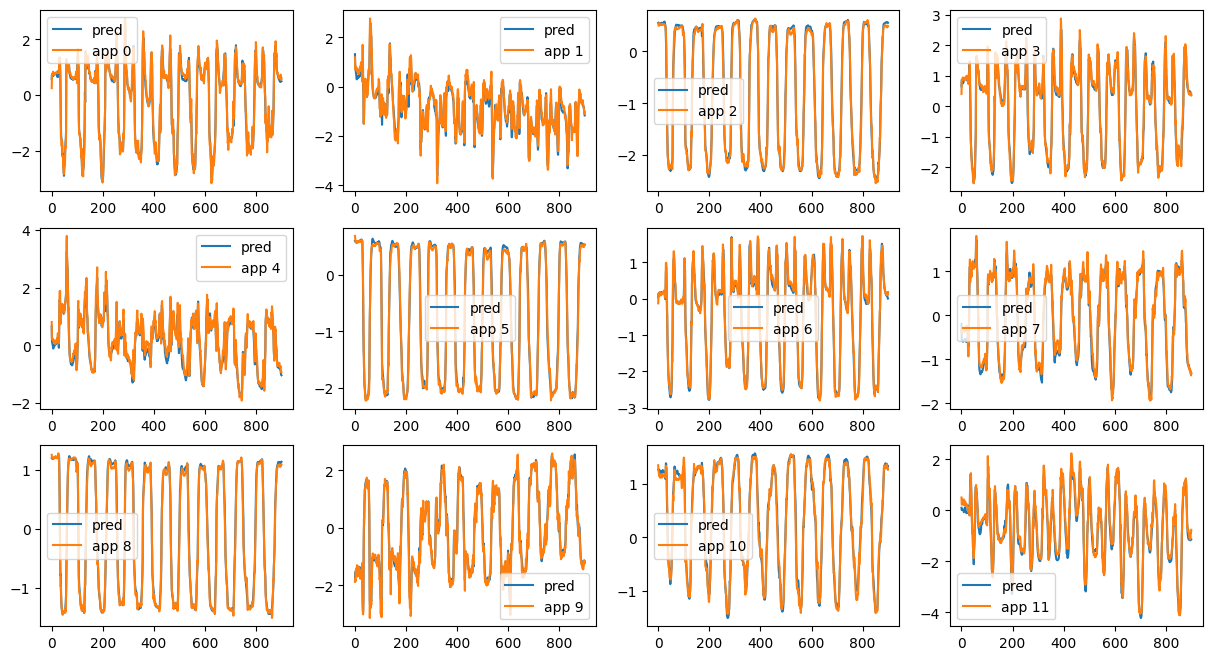

In [25]:
fig, ax = plt.subplots(3, 4, figsize=(15, 8))

ax = ax.flatten()

for i in range(12):

    ax[i].plot(pred_appendage[:900, i], label="pred")
    ax[i].plot(appendage_values[:900, i], label=f"app {i}")
    ax[i].legend()

plt.show()

In [ ]:
with torch.no_grad():
    vqvae_toks = vqvae(appendage_batch.to(torch.float32).to(device), return_toks=True)

torch.Size([1, 900])


(array([36., 11.,  9.,  0.,  2., 19.,  0.,  7.,  0.,  0.,  0.,  0.,  0.,
         0.,  4.,  6.,  0.,  0.,  0.,  0.,  0.,  4.,  4.,  0.,  0.,  0.,
         0.,  5.,  1.,  0., 13.,  0.,  0.,  0.,  0.,  0., 14., 10., 30.,
         7.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., 17.]),
 array([ 1.  ,  1.94,  2.88,  3.82,  4.76,  5.7 ,  6.64,  7.58,  8.52,
         9.46, 10.4 , 11.34, 12.28, 13.22, 14.16, 15.1 , 16.04, 16.98,
        17.92, 18.86, 19.8 , 20.74, 21.68, 22.62, 23.56, 24.5 , 25.44,
        26.38, 27.32, 28.26, 29.2 , 30.14, 31.08, 32.02, 32.96, 33.9 ,
        34.84, 35.78, 36.72, 37.66, 38.6 , 39.54, 40.48, 41.42, 42.36,
        43.3 , 44.24, 45.18, 46.12, 47.06, 48.  ]),
 <BarContainer object of 50 artists>)

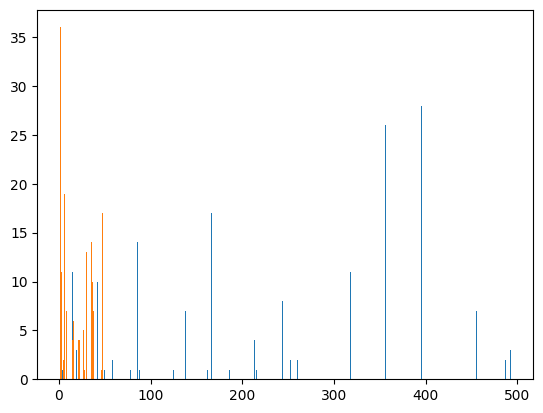

In [ ]:
print(vqvae_toks.shape)
plt.hist(vqvae_toks.squeeze(0).cpu()[:200], bins=512)
plt.hist(region_batch.squeeze(0).cpu()[:200], bins=50)

This tells us that the tokens are diverse across the VQVAE codebook tokens while the KMeans clustering is high in some places.